# Release year Thalweg

In [23]:
import cmocean.cm as cm
import copy
from matplotlib import pyplot as plt,colors
import numpy as np
import xarray as xr
import pandas as pd
import netCDF4 as NC
import itertools
from matplotlib import pylab
import sys 
from matplotlib.colors import LogNorm

#
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [2]:
coords = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')
bathy = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid/bathymetry_202108.nc')
volume = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')['volume']

In [3]:
x = np.linspace(0,397,398)
y = np.linspace(0,897,898)
X, Y =np.meshgrid(x,y)

In [4]:
thalweg= np.loadtxt('my_thalweg.txt', delimiter=' ', dtype=int)

In [5]:
def distance(thalweg,dx,dy):
    leng=thalweg.shape
    l =leng[0]
    distance = np.zeros(l)
    d=0
    
    for k in range(1,l):
        i1=thalweg[k-1,1]; i2=thalweg[k,1];
        j1=thalweg[k-1,0]; j2=thalweg[k,0];
        dseg =( (dx*(i2-i1))**2 + (dy*(j2-j1))**2)**(0.5)
        d=d+dseg
        distance[k]=d;

    return distance

In [6]:
dist = distance(thalweg, dx=400, dy=500); dist=dist/1000

In [7]:
bat_mask = []
for i in range(0,len(dist)-1):
    bat_mask.append(bathy['Bathymetry'][thalweg[i][0], thalweg[i][1]].values)

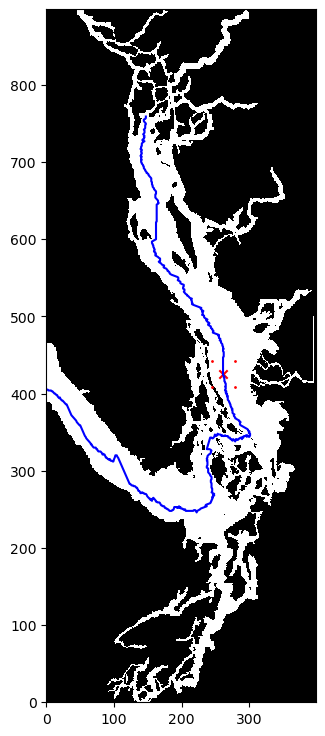

In [8]:
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
dd = 17
idx = 450
fig, ax = plt.subplots(figsize = (5,9))
ax.pcolormesh(mask['tmask'][0,0], cmap = cmap)
ax.set_aspect(1.14)
pylab.plot(thalweg[:,1],thalweg[:,0],color='b')
ax.scatter(thalweg[idx][1], thalweg[idx][0], c = 'r', marker = 'x')
ax.scatter(thalweg[idx][1]+dd, thalweg[idx][0]+dd, s = 1, c = 'r')
ax.scatter(thalweg[idx][1]-dd, thalweg[idx][0]-dd, s = 1, c = 'r')
ax.scatter(thalweg[idx][1]-dd, thalweg[idx][0]+dd, s = 1, c = 'r')
ax.scatter(thalweg[idx][1]+dd, thalweg[idx][0]-dd, s = 1, c = 'r')


In [9]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [10]:
source_lat = 49.195045
source_lon = -123.301956
s_y, s_x = finder2(source_lat, source_lon, mask)

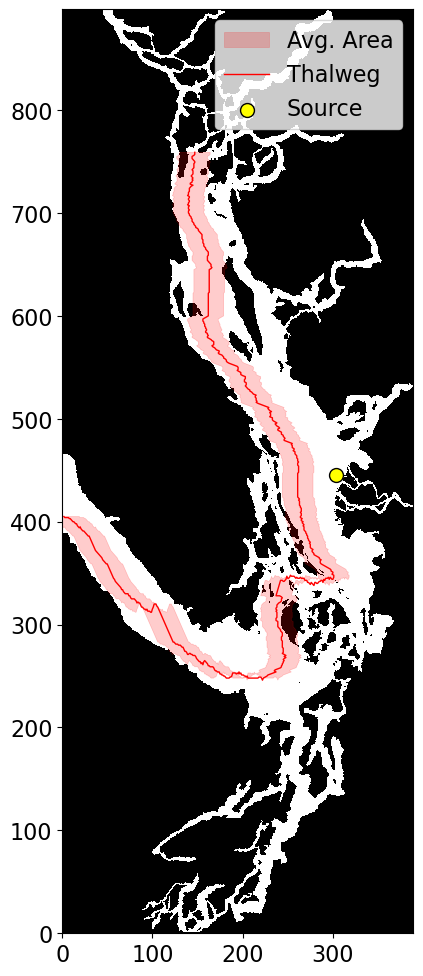

In [29]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig, ax = plt.subplots(figsize=(6, 12))
ax.pcolormesh(mask['tmask'][0, 0], cmap=cmap)
ax.set_aspect(1.14)

# 1. Create the 'Envelope' Coordinates
# We use the thalweg path and offset it laterally
left_side_x = thalweg[:, 1] - dd
left_side_y = thalweg[:, 0]
right_side_x = thalweg[:, 1] + dd
right_side_y = thalweg[:, 0]

# 2. Combine into a single Polygon for a clean 'Ribbon'
# We flip the right side to create a continuous loop around the thalweg
verts = [
    *zip(left_side_x, left_side_y),
    *zip(right_side_x[::-1], right_side_y[::-1])
]
poly = Polygon(verts, facecolor='red', alpha=0.2, edgecolor='r', linewidth=0.5, label='Avg. Area')
ax.add_patch(poly)

# 3. Plot the Thalweg Core
ax.plot(thalweg[:, 1], thalweg[:, 0], color='r', linewidth=1, label='Thalweg')

s_y, s_x = finder2(source_lat, source_lon, mask)
ax.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Source')

ax.set_xlim(0,389)
ax.legend()
plt.show()

In [11]:
from scipy.spatial import cKDTree

def get_grid_indices_vectorized(part_lons, part_lats, mask):
    #
    grid_lats = mask.nav_lat.values.flatten()
    grid_lons = mask.nav_lon.values.flatten()
    tree = cKDTree(np.c_[grid_lats, grid_lons])
    
    #
    _, indices = tree.query(np.c_[part_lats, part_lons])
    
    #
    shape_x = mask.nav_lon.shape[1]
    return indices // shape_x, indices % shape_x

In [12]:

from matplotlib.colors import LogNorm

def create_robust_swath(data, thalweg, mask, d_km, dd=17, num_z_bins=40):
    status = data['status'].values.flatten()
    idx_wat = (status > 0) & (status < 4)
    
    p_lons = data['lon'].values.flatten()[idx_wat]
    p_lats = data['lat'].values.flatten()[idx_wat]
    p_depths = data['z'].values.flatten()[idx_wat]

    #
    p_y, p_x = get_grid_indices_vectorized(p_lons, p_lats, mask)

    # 3. Create 3D Histogram (Z, Y, X)
    y_bins = np.arange(0, mask.nav_lat.shape[0] + 1)
    x_bins = np.arange(0, mask.nav_lat.shape[1] + 1)
    z_bins = np.linspace(0, 450, num_z_bins + 1) # Adjust max depth to your bathy
    
    grid_3d, _ = np.histogramdd(
        (p_depths, p_y, p_x), 
        bins=(z_bins, y_bins, x_bins)
    )

    # 4. Swath Extraction with tmask
    tmask = mask['tmask'][0, 0].values
    swath_matrix = np.zeros((num_z_bins, len(thalweg)))

    print("Sliding swath box along thalweg...")
    for i, pt in enumerate(thalweg):
        y_c, x_c = int(pt[0]), int(pt[1])
        
        # Define box bounds with grid clipping
        y0, y1 = max(0, y_c - dd), min(grid_3d.shape[1], y_c + dd + 1)
        x0, x1 = max(0, x_c - dd), min(grid_3d.shape[2], x_c + dd + 1)
        
        # Local mask for the box
        local_mask = tmask[y0:y1, x0:x1]
        
        for k in range(num_z_bins):
            # Only sum counts where tmask == 1 (water)
            box_counts = grid_3d[k, y0:y1, x0:x1]
            swath_matrix[k, i] = np.sum(box_counts[local_mask == 1])

    return swath_matrix, z_bins

In [13]:
def smooth_array(data, window_size=5):
    """Smooths array using a moving average while maintaining length."""
    window = np.ones(int(window_size)) / float(window_size)
    return np.convolve(data, window, 'same')

bat_mask_raw = np.array(bat_mask)
bat_mask_smooth = smooth_array(bat_mask_raw, window_size=7) 

bat_mask_smooth[0] = bat_mask_raw[0]
bat_mask_smooth[-1] = bat_mask_raw[-1]

In [14]:
thalweg_lats = mask.nav_lat.values[thalweg[:,0], thalweg[:,1]]
thalweg_lons = mask.nav_lon.values[thalweg[:,0], thalweg[:,1]]

dist_to_source = np.sqrt((thalweg_lats - source_lat)**2 + (thalweg_lons - source_lon)**2)
source_idx = np.argmin(dist_to_source)

source_dist_km = dist[source_idx]

In [16]:
filename1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']
#
data = xr.open_dataset(filename1, drop_variables=[v for v in xr.open_dataset(filename1).variables if v not in vars_to_keep])

In [21]:
with xr.open_dataset(filename1, drop_variables=[v for v in xr.open_dataset(filename1).variables if v not in vars_to_keep]) as data_combined:
    data_week1 = data_combined.isel(obs = slice(0,8*7))
    data_week2 = data_combined.isel(obs = slice(0,8*14))
    data_month1 = data_combined.isel(obs = slice(0, 8*30))
    data_month3 = data_combined.isel(obs = slice(0, 8*90))
    data_month6 = data_combined.isel(obs = slice(0, 8*180))
    data_month9 = data_combined.isel(obs = slice(0, 8*270))
    data_month12 = data_combined.isel(obs = slice(0, 8*365))

In [22]:
swath_week1, z_week1 = create_robust_swath(data_week1, thalweg, mask, dist)
z_centers_week1 = (z_week1[:-1] + z_week1[1:]) / 2
#
swath_week2, z_week2 = create_robust_swath(data_week2, thalweg, mask, dist)
z_centers_week2 = (z_week2[:-1] + z_week2[1:]) / 2
#
swath_month1, z_month1 = create_robust_swath(data_month1, thalweg, mask, dist)
z_centers_month1 = (z_month1[:-1] + z_month1[1:]) / 2
#
swath_month3, z_month3 = create_robust_swath(data_month3, thalweg, mask, dist)
z_centers_month3 = (z_month3[:-1] + z_month3[1:]) / 2
#
swath_month6, z_month6 = create_robust_swath(data_month6, thalweg, mask, dist)
z_centers_month6 = (z_month6[:-1] + z_month6[1:]) / 2
#
swath_month9, z_month9 = create_robust_swath(data_month9, thalweg, mask, dist)
z_centers_month9 = (z_month9[:-1] + z_month9[1:]) / 2
#
swath_month12, z_month12 = create_robust_swath(data_month12, thalweg, mask, dist)
z_centers_month12 = (z_month12[:-1] + z_month12[1:]) / 2

Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...
Sliding swath box along thalweg...


In [24]:
z_list = [z_centers_week1, z_centers_week2, z_centers_month1, z_centers_month3, z_centers_month6, z_centers_month9, z_centers_month12]
swath_list = [swath_week1, swath_week2, swath_month1, swath_month3, swath_month6, swath_month9, swath_month12]

/tmp/ipykernel_1837279/3006568745.py:18: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = ax.contourf(dist, z_list[i], current_swath,


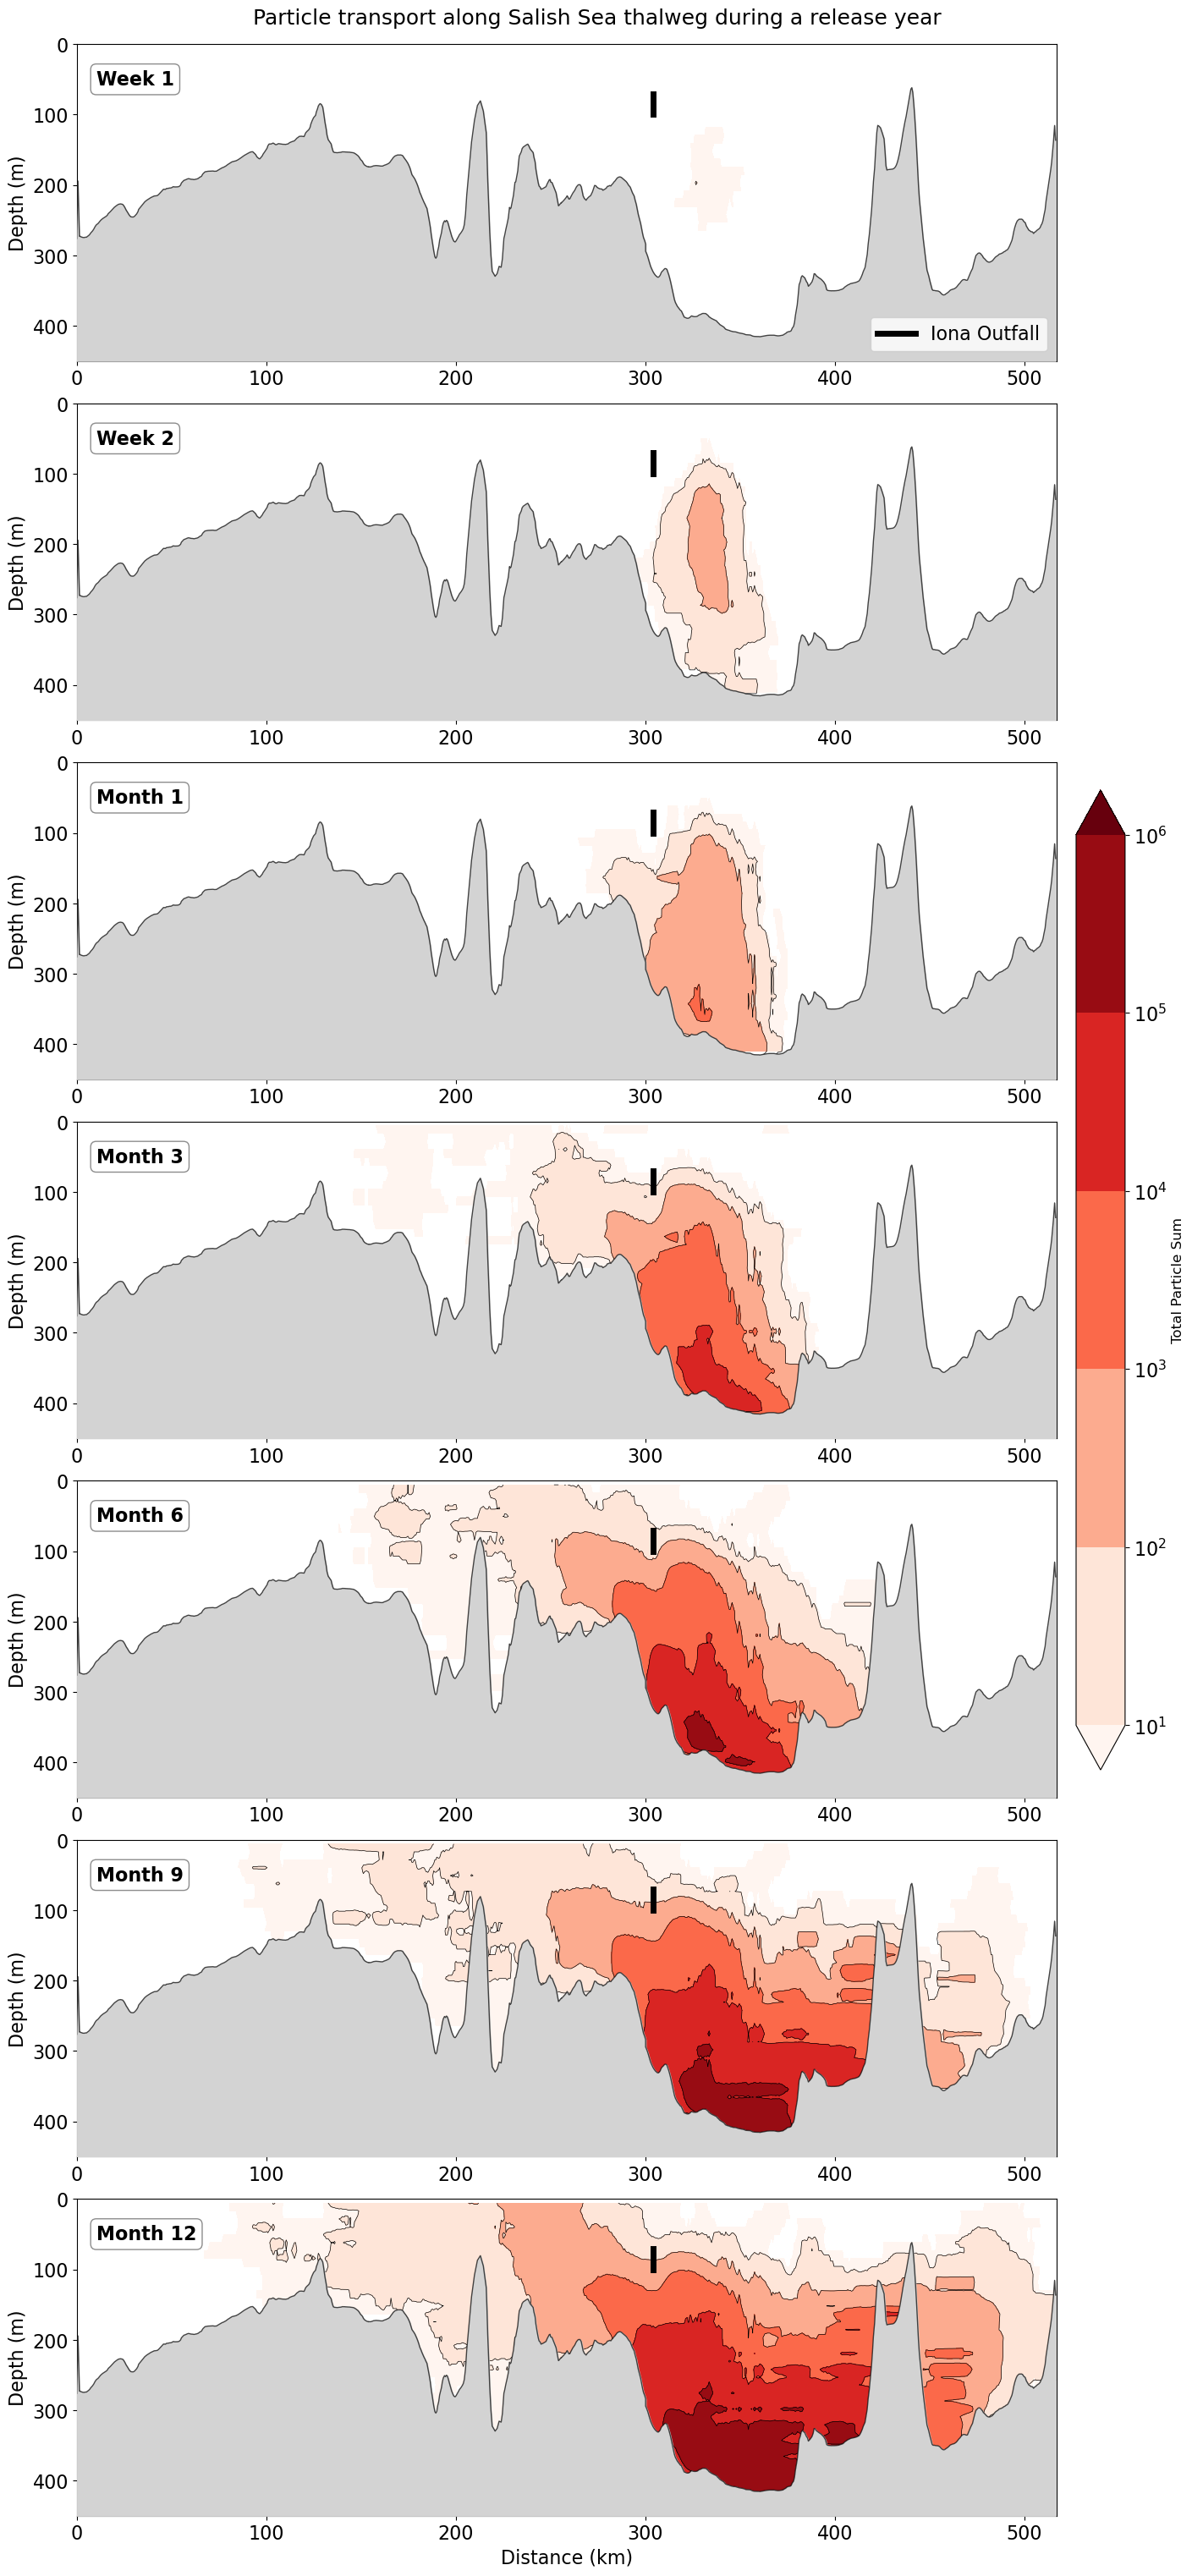

In [28]:
plt.rcParams.update({'font.size': 16})
# 1. Configuration
time_labels = ['Week 1', 'Week 2', 'Month 1', 'Month 3', 'Month 6', 'Month 9', 'Month 12']
levels = [10, 100, 1000, 10000, 100000, 1000000]

# Use layout='constrained' to prevent titles/labels from overlapping
fig, axes = plt.subplots(7, 1, figsize=(14, 30), layout='constrained')

for i in range(len(swath_list)):
    ax = axes[i]
    
    # Handle dimension alignment
    # We ensure the columns of the data match the length of the distance array
    current_swath = swath_list[i] if swath_list[i].shape[1] == len(dist) else swath_list[i].T
    
    # 2. Plotting the Particle Data
    # We save the 'cntr' object from the plots to use for the single colorbar
    cntr = ax.contourf(dist, z_list[i], current_swath, 
                       levels=levels, 
                       cmap='Reds',
                       norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                       extend='both', zorder=1)
    
    # 3. Line Contours for clarity
    ax.contour(dist, z_list[i], current_swath, 
               levels=levels, 
               colors='black', 
               linewidths=0.5, zorder=2)
    
    # 4. Bathymetry Mask
    ax.fill_between(dist[:-1], bat_mask_smooth, 450, color='lightgrey', zorder=3)
    ax.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=4)
    
    # 5. Outfall Marker (Vertical line at the source distance)
    ax.plot([source_dist_km, source_dist_km], [70,100], 'k', linewidth = 5, label = 'Iona Outfall')
    
    # 6. Per-panel Formatting
    ax.invert_yaxis()
    ax.set_ylim(450, 0)
    ax.set_xlim(dist.min(), dist.max())
    ax.set_ylabel("Depth (m)")
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.9)
    ax.text(0.02, 0.92, f'{time_labels[i]}', transform=ax.transAxes, 
            fontweight='bold', verticalalignment='top', bbox=bbox_props, zorder=5)
    
    if i == 0:
        ax.legend(loc='lower right')
    if i == 6:
        ax.set_xlabel('Distance (km)')    

# 7. THE MASTER COLORBAR
# 'ax=axes' tells matplotlib to steal space from all subplots equally
cbar = fig.colorbar(cntr, ax=axes, orientation='vertical', fraction=0.05, pad=0.02, ticks=levels)
cbar.set_label('Total Particle Sum', fontsize=12)

# Set the tick labels to scientific notation for readability
cbar.ax.set_yticklabels([f'$10^{int(np.log10(l))}$' for l in levels])

plt.suptitle('Particle transport along Salish Sea thalweg during a release year', fontsize=18, y=1.01)
plt.show()

In [30]:
def particles_amount(
    lons, lats, mask=mask, num_lon=200, num_lat=200
):
    # Convert to numpy (avoids xarray overhead inside histogram)
    nav_lon = mask['nav_lon'].values
    nav_lat = mask['nav_lat'].values

    # Bin edges
    lon_edges = np.linspace(nav_lon.min(), nav_lon.max(), num_lon + 1)
    lat_edges = np.linspace(nav_lat.min(), nav_lat.max(), num_lat + 1)

    # Bin centers
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2

    # Histogram for ALL particles
    counts, xedges, yedges = np.histogram2d(
        lons, lats,
        bins=[lon_edges, lat_edges]
    )

    df = pd.DataFrame(
        counts.T,  # lat rows, lon cols
        index=lat_centers,
        columns=lon_centers
    )

    # 🔥 Build grid indices MUCH faster
    Xcenters, Ycenters = np.meshgrid(lon_centers, lat_centers)

    # Flatten once
    flat_lon = Xcenters.ravel()
    flat_lat = Ycenters.ravel()

    ii_sed = np.zeros(flat_lon.size, dtype=int)
    jj_sed = np.zeros(flat_lon.size, dtype=int)

    for k in range(flat_lon.size):
        jj, ii = finder2(flat_lat[k], flat_lon[k], mask)
        ii_sed[k] = ii
        jj_sed[k] = jj

    ii_sed = ii_sed.reshape(Xcenters.shape)
    jj_sed = jj_sed.reshape(Ycenters.shape)

    grid_indices = (ii_sed, jj_sed)

    raw_hist = (counts, xedges, yedges)

    return df, raw_hist, grid_indices


In [31]:
amount_week1, _, grid_ij1 = particles_amount(data_week1['lon'].values.flatten(), data_week1['lat'].values.flatten())
amount_week2, _, grid_ij2 = particles_amount(data_week2['lon'].values.flatten(), data_week2['lat'].values.flatten())
amount_month1, _, grid_ij3 = particles_amount(data_month1['lon'].values.flatten(), data_month1['lat'].values.flatten())
amount_month3, _, grid_ij4 = particles_amount(data_month3['lon'].values.flatten(), data_month3['lat'].values.flatten())
amount_month6, _, grid_ij5 = particles_amount(data_month6['lon'].values.flatten(), data_month6['lat'].values.flatten())
amount_month9, _, grid_ij6 = particles_amount(data_month9['lon'].values.flatten(), data_month9['lat'].values.flatten())
amount_month12, _, grid_ij7 = particles_amount(data_month12['lon'].values.flatten(), data_month12['lat'].values.flatten())

/tmp/ipykernel_1837279/2016952949.py:16: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  caca1 = ax[0].pcolormesh(grid_ij1[0], grid_ij1[1], amount_week1,
/tmp/ipykernel_1837279/2016952949.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  caca2 = ax[1].pcolormesh(grid_ij2[0], grid_ij2[1], amount_week2,
/tmp/ipykernel_1837279/2016952949.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolo

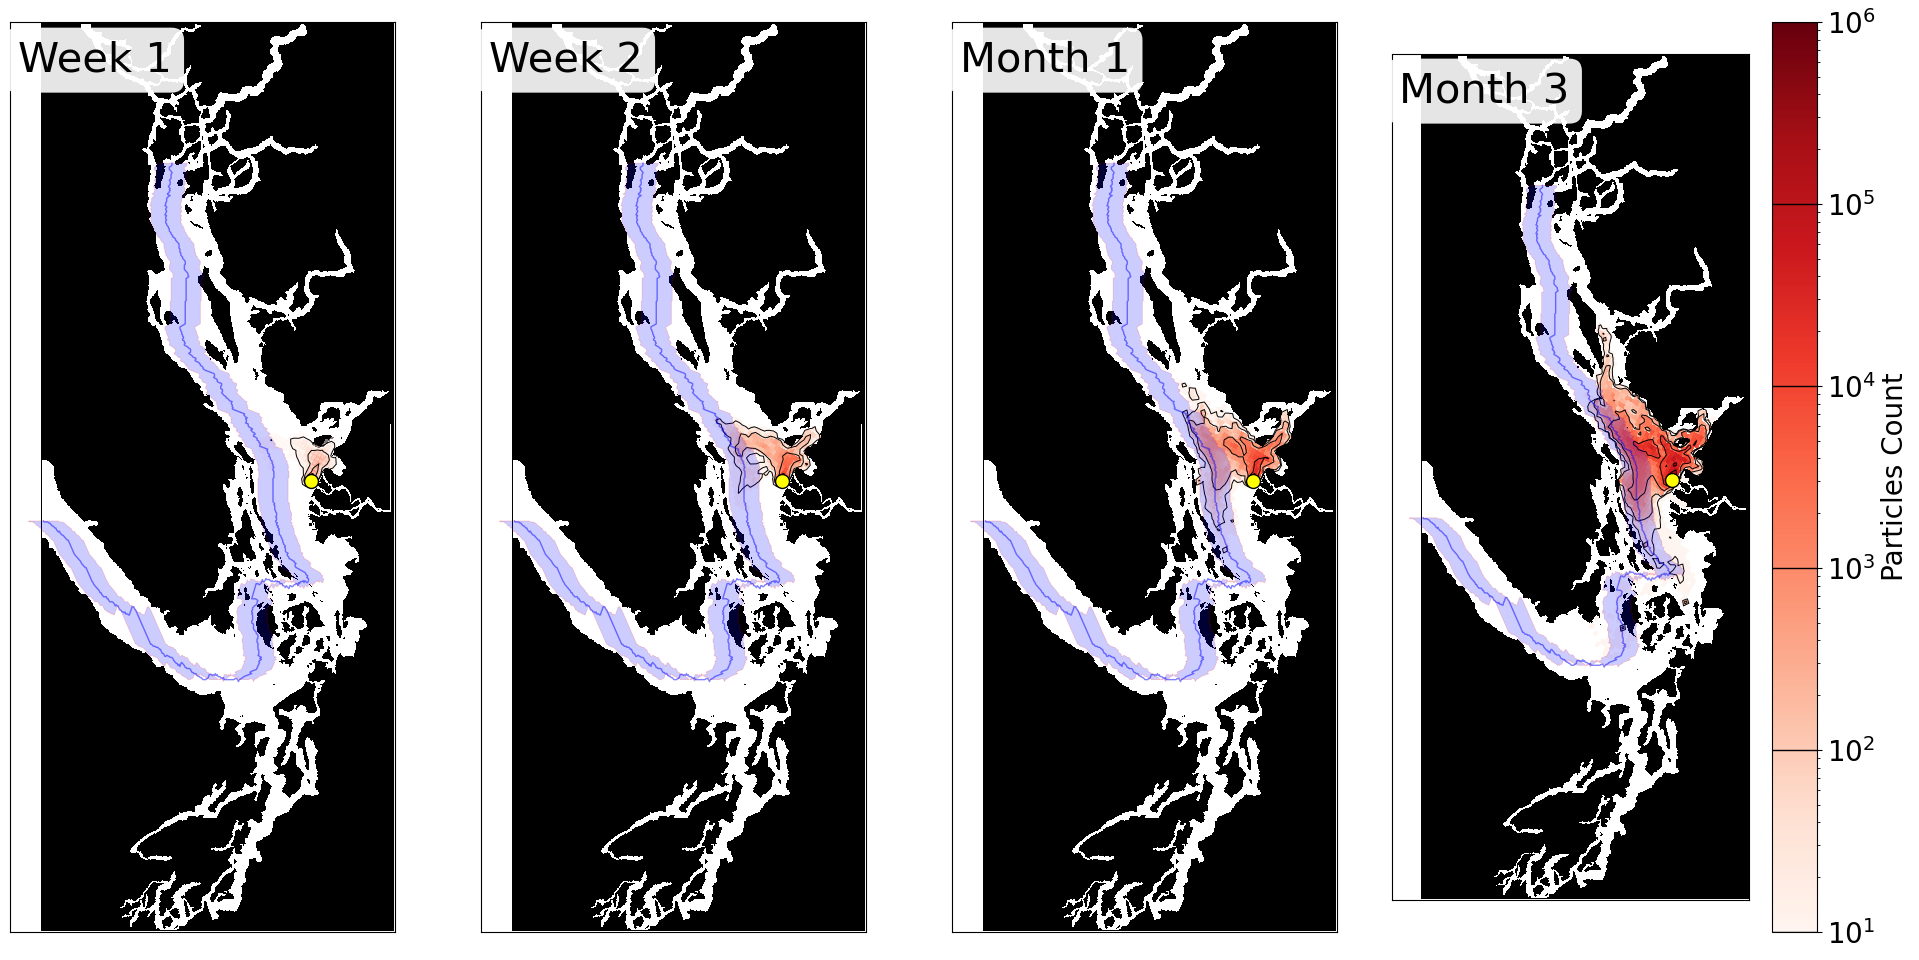

In [40]:
plt.rcParams.update({'font.size': 20})
from matplotlib.colors import ListedColormap, BoundaryNorm
# Colormap for mask
colors_0 = [(0, 0, 0, 1),  # Black for land
          (0, 0, 0, 0)]  # Transparent for water
cmap = ListedColormap(colors_0)
#
x = np.linspace(0,397,398)
y = np.linspace(0,897,898)
X, Y =np.meshgrid(x,y)
#

fig, ax = plt.subplots(1, 4, figsize = (20, 10))
ax[0].pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)

caca1 = ax[0].pcolormesh(grid_ij1[0], grid_ij1[1], amount_week1, 
                         norm=LogNorm(vmin=levels[0], vmax=levels[-1]), cmap = 'Reds',
                         alpha = .5, zorder = 1)
ax[0].contour(grid_ij1[0], grid_ij1[1], amount_week1, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid', zorder = 1)
#
ax[1].pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)
caca2 = ax[1].pcolormesh(grid_ij2[0], grid_ij2[1], amount_week2, 
                         norm=LogNorm(vmin=levels[0], vmax=levels[-1]), cmap = 'Reds', zorder = 1)
ax[1].contour(grid_ij2[0], grid_ij2[1], amount_week2, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid', zorder = 1)

#
ax[2].pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)
caca3 = ax[2].pcolormesh(grid_ij3[0], grid_ij3[1], amount_month1, 
                         norm=LogNorm(vmin=levels[0], vmax=levels[-1]), cmap = 'Reds', zorder = 1)
ax[2].contour(grid_ij3[0], grid_ij3[1], amount_month1, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid', zorder = 1)

#
ax[3].pcolormesh(X,Y,mask['tmask'][0][0], cmap=cmap)
caca4 = ax[3].pcolormesh(grid_ij4[0], grid_ij4[1], amount_month3, 
                         norm=LogNorm(vmin=levels[0], vmax=levels[-1]), cmap = 'Reds', zorder = 1)
ax[3].contour(grid_ij4[0], grid_ij4[1], amount_month3, colors='black', levels = levels
              ,linewidths=0.7, linestyles='solid', zorder = 1)

cb4 = plt.colorbar(caca4, ax = ax[3])
cb4.set_label('Particles Count')
for lev in levels:
    cb4.ax.hlines(
        lev, 
        *cb4.ax.get_xlim(),   # span full width
        colors='black',
        linewidth=1
    )
#
for axis in ax:
    axis.set_aspect(1.14)
    axis.set_xticks([])
    axis.set_yticks([])
#
labels = ['Week 1', 'Week 2', 'Month 1', 'Month 3']

for axis, label in zip(ax, labels):
    axis.text(
        0.02, 0.98,
        label,
        transform=axis.transAxes,
        ha='left',
        va='top',
        fontsize=30,
        bbox=dict(
            facecolor='white',
            edgecolor='none',
            alpha=0.9,
            boxstyle='round,pad=0.3'
        )
    )
for axis in ax:
    left_side_x = thalweg[:, 1] - dd
    left_side_y = thalweg[:, 0]
    right_side_x = thalweg[:, 1] + dd
    right_side_y = thalweg[:, 0]


    verts = [
        *zip(left_side_x, left_side_y),
        *zip(right_side_x[::-1], right_side_y[::-1])
    ]
    poly = Polygon(verts, facecolor='b', alpha=0.2, edgecolor='r', linewidth=0.5, label='Avg. Area', zorder = 4)
    axis.add_patch(poly)

    axis.plot(thalweg[:, 1], thalweg[:, 0], color='b', alpha = .5, linewidth=1, label='Thalweg', zorder = 4)

    s_y, s_x = finder2(source_lat, source_lon, mask)
    axis.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='Source')
plt.tight_layout()

/tmp/ipykernel_1837279/2096645424.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = ax_left.contourf(dist, z_list[i], current_swath,
/tmp/ipykernel_1837279/2096645424.py:70: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax_right.pcolormesh(grid_list[i][0], grid_list[i][1], amount_list[i],
/tmp/ipykernel_1837279/2096645424.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  cntr = ax_left.contourf(dist, z_list[i], current_swath,
/tmp/ipykernel_1837279/2096645424.py:70: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax_right.pcolormesh(grid_list[

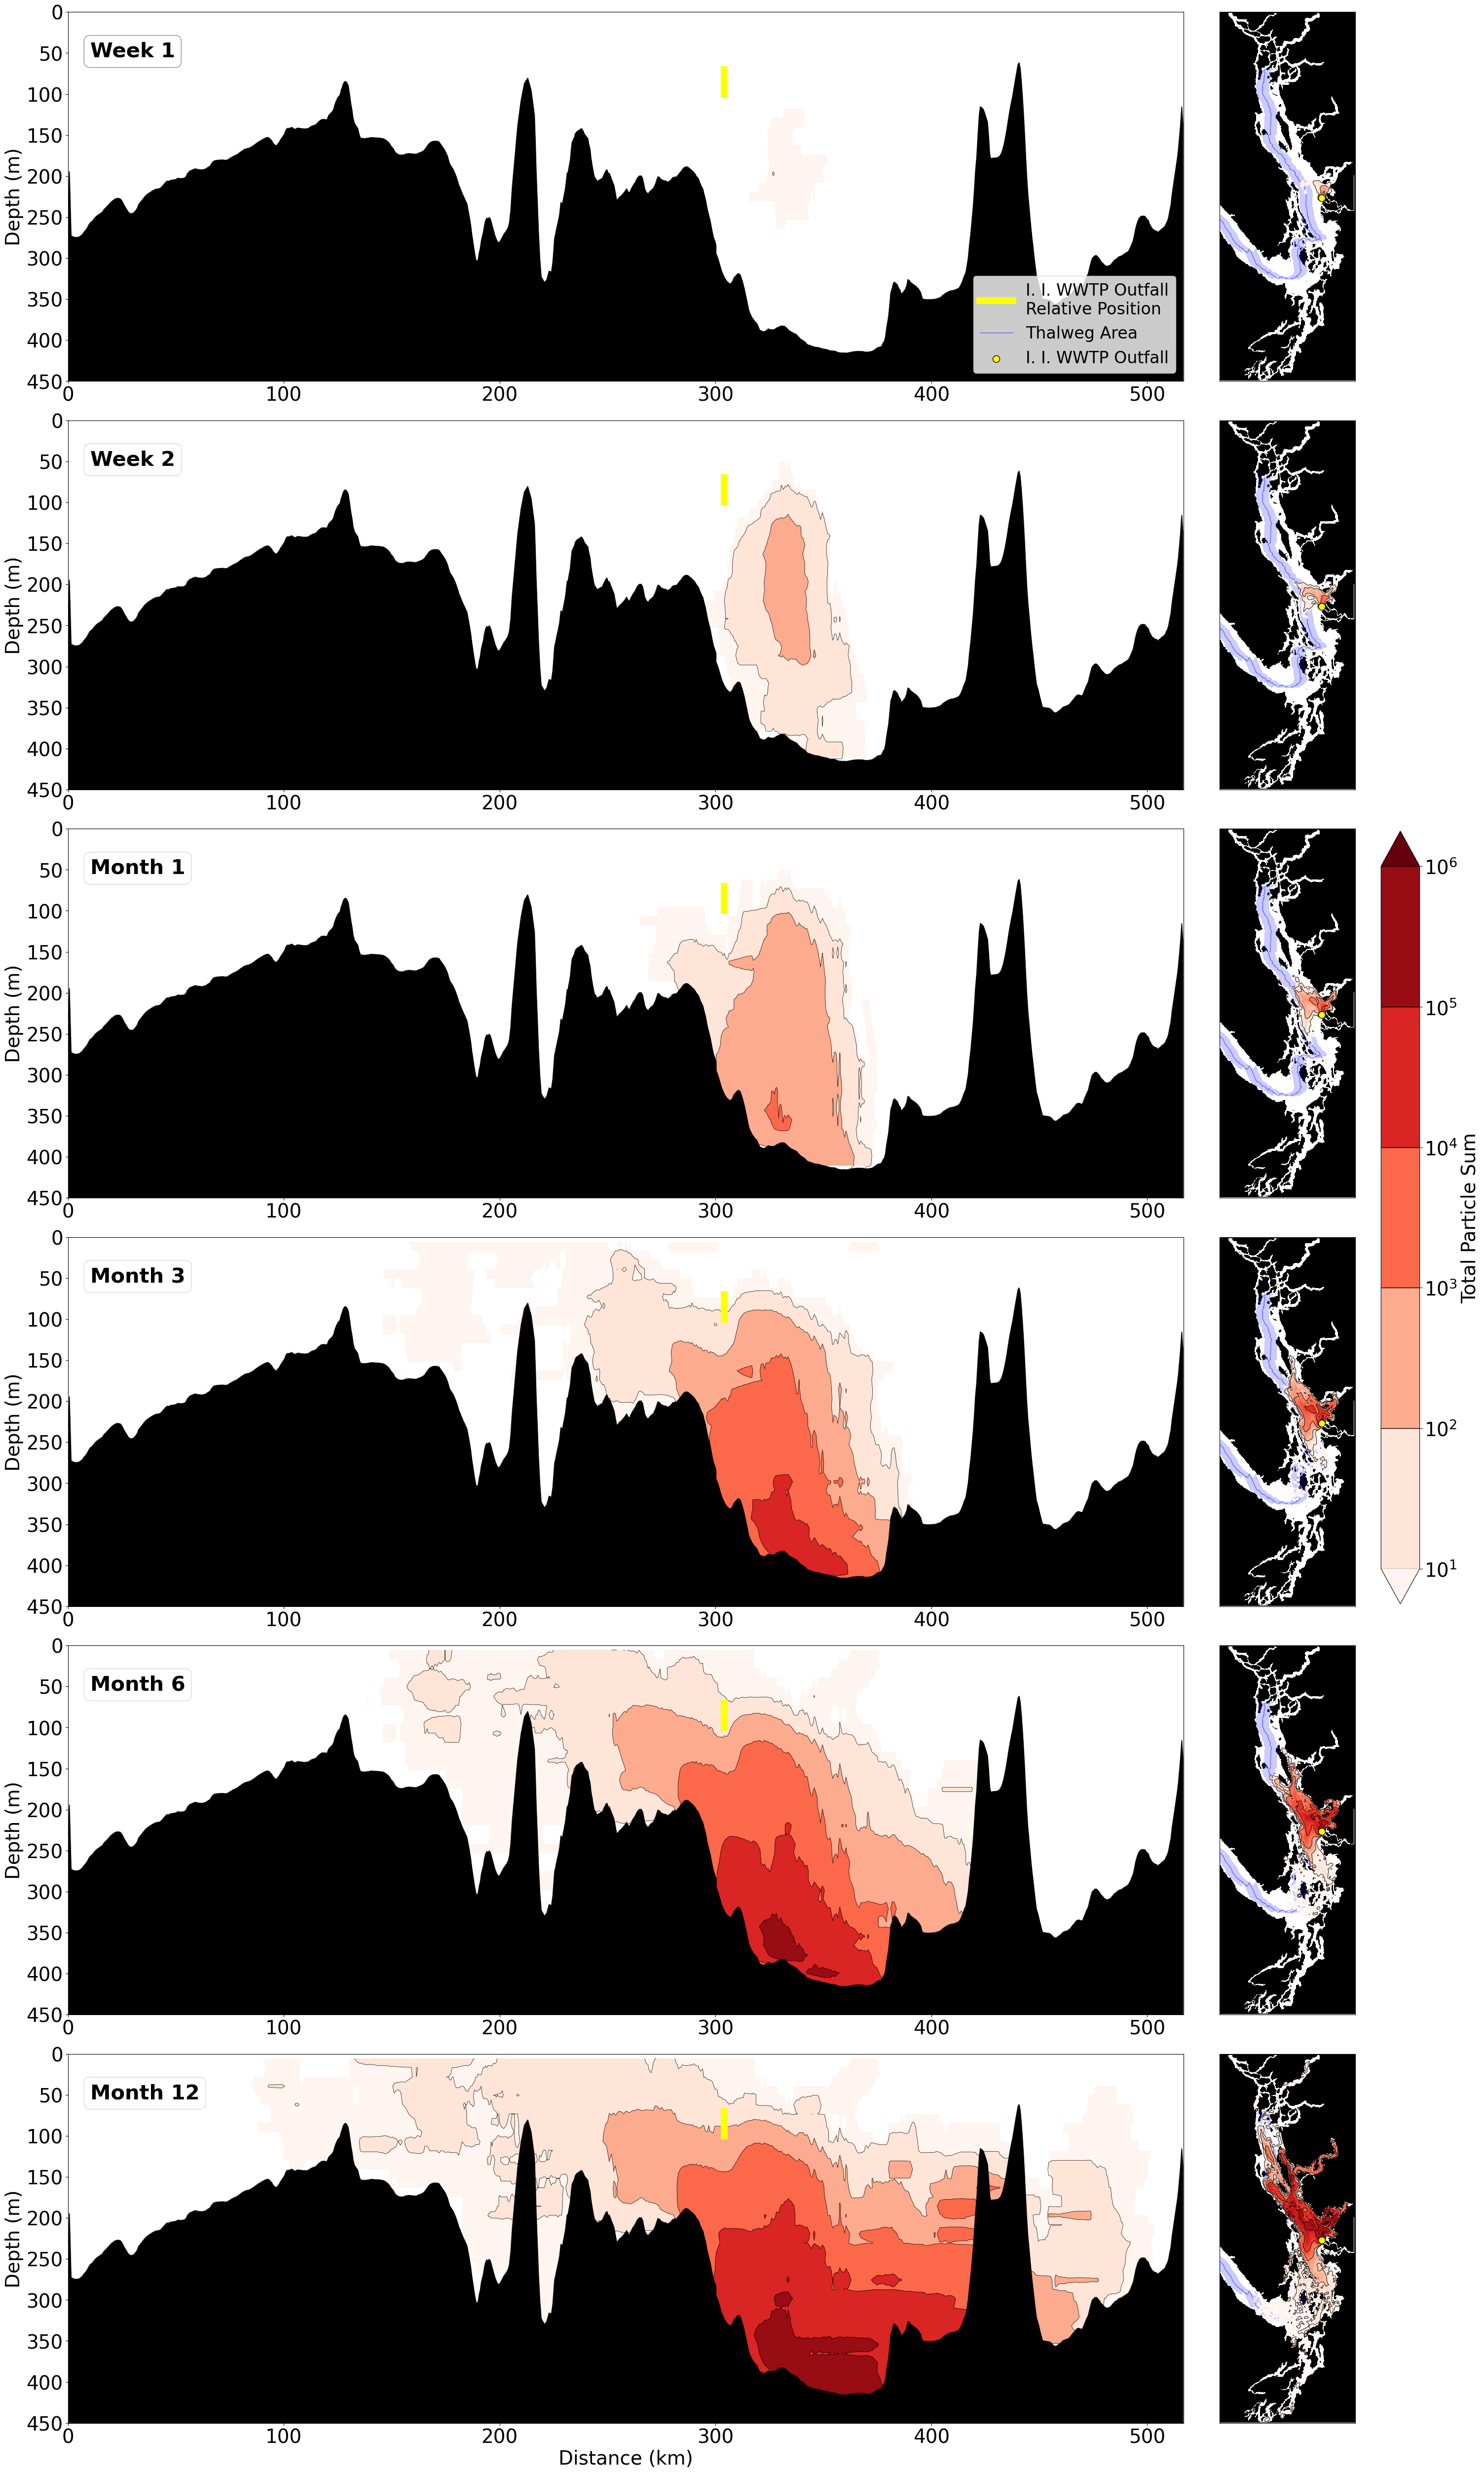

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LogNorm
from matplotlib.patches import Polygon

plt.rcParams.update({'font.size': 28})

# 1. Configuration & Shared Variables
time_labels = ['Week 1', 'Week 2', 'Month 1', 'Month 3', 'Month 6', 'Month 12']
levels = [10, 100, 1000, 10000, 100000, 1000000]
#
grid_list = [grid_ij1, grid_ij2, grid_ij3, grid_ij4, grid_ij5, grid_ij7] 
amount_list = [amount_week1, amount_week2, amount_month1, amount_month3, amount_month6, amount_month12]

colors_0 = [(0, 0, 0, 1), (0, 0, 0, 0)]
cmap_mask = ListedColormap(colors_0)

x = np.linspace(0, 397, 398)
y = np.linspace(0, 897, 898)
X, Y = np.meshgrid(x, y)

fig, axes = plt.subplots(6, 2, figsize=(30, 50), 
                         layout='constrained',
                         gridspec_kw={'width_ratios': [4, 0.6], 'wspace': 0.0})
bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.9)

# 3. Main Plotting Loop
for i in range(6):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]
    
    current_swath = swath_list[i] if swath_list[i].shape[1] == len(dist) else swath_list[i].T
    
    cntr = ax_left.contourf(dist, z_list[i], current_swath, 
                            levels=levels, cmap='Reds',
                            norm=LogNorm(vmin=levels[0], vmax=levels[-1]), 
                            extend='both', zorder=1)
    
    ax_left.contour(dist, z_list[i], current_swath, 
                    levels=levels, colors='black', 
                    linewidths=0.5, zorder=2)
    
    ax_left.fill_between(dist[:-1], bat_mask_smooth, 450, color='k', zorder=3)
    ax_left.plot(dist[:-1], bat_mask_smooth, color='black', linewidth=1, alpha=0.7, zorder=4)
    
    ax_left.plot([source_dist_km, source_dist_km], [70,100], 'yellow', linewidth = 10 , 
                 label='I. I. WWTP Outfall' + '\n' + 'Relative Position')
    
    ax_left.invert_yaxis()
    ax_left.set_ylim(450, 0)
    ax_left.set_xlim(dist.min(), dist.max())
    ax_left.set_ylabel("Depth (m)")
    
    # Top-left label for thalweg plot
    ax_left.text(0.02, 0.92, f'{time_labels[i]}', transform=ax_left.transAxes, fontsize = 30,
                 fontweight='bold', verticalalignment='top', bbox=bbox_props, zorder=5)
    bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=1, alpha=0.3)
    
    #if i == 0:
    #    ax_left.legend(loc='lower right', fontsize = 20)
    #if i == 6:
    #    ax_left.set_xlabel('Distance (km)')

    # =======================================================
    # RIGHT COLUMN: Map View Distribution
    # =======================================================
    ax_right.pcolormesh(X, Y, mask['tmask'][0][0], cmap=cmap_mask, zorder=0)
    
    # Plot the particle distribution
    ax_right.pcolormesh(grid_list[i][0], grid_list[i][1], amount_list[i], 
                        norm=LogNorm(vmin=levels[0], vmax=levels[-1]), cmap='Reds', zorder=3)
    
    ax_right.contour(grid_list[i][0], grid_list[i][1], amount_list[i], 
                     colors='black', levels=levels, linewidths=0.7, linestyles='solid', zorder=4)
    
    # Plot Thalweg Area Polygon
    left_side_x = thalweg[:, 1] - dd
    left_side_y = thalweg[:, 0]
    right_side_x = thalweg[:, 1] + dd
    right_side_y = thalweg[:, 0]

    verts = [
        *zip(left_side_x, left_side_y),
        *zip(right_side_x[::-1], right_side_y[::-1])
    ]
    poly = Polygon(verts, facecolor='b', alpha=0.2, edgecolor='b', linewidth=0.5, zorder=2)
    ax_right.add_patch(poly)

    # Plot Thalweg Line and Source
    ax_right.plot(thalweg[:, 1], thalweg[:, 0], color='b', alpha=0.5, linewidth=1, label='Thalweg Area', zorder=2)
    s_y, s_x = finder2(source_lat, source_lon, mask)
    ax_right.scatter(s_x, s_y, color='yellow', edgecolor='black', s=100, zorder=5, label='I. I. WWTP Outfall')
    
    # Map formatting
    ax_right.set_xlim(20,398)
    ax_right.set_aspect(1.14)
    ax_right.set_anchor('W')  # <--- NEW: Pins the map tightly to the left plot    
    ax_right.set_xticks([])
    ax_right.set_yticks([])

    if i == 0:
        # Grab the drawn objects and labels from BOTH subplots
        handles_left, labels_left = ax_left.get_legend_handles_labels()
        handles_right, labels_right = ax_right.get_legend_handles_labels()
        
        # Combine them and plot the master legend on the left subplot
        ax_left.legend(handles_left + handles_right, labels_left + labels_right, 
                       loc='lower right', fontsize=24)
        
    if i == 5: # Changed from 6 to 5 so it triggers on the last row
        ax_left.set_xlabel('Distance (km)')


# 4. ONE MASTER COLORBAR FOR THE WHOLE FIGURE
# Setting ax=axes passes the entire array of subplots, making the colorbar span the height of the figure on the right
cbar = fig.colorbar(cntr, ax=axes, orientation='vertical', fraction=0.03, pad=0.02, ticks=levels)
cbar.set_label('Total Particle Sum')

# Format scientific notation
cbar.ax.set_yticklabels([f'$10^{{{int(np.log10(l))}}}$' for l in levels])

# Add horizontal marker lines across the colorbar
for lev in levels:
    cbar.ax.hlines(lev, *cbar.ax.get_xlim(), colors='black', linewidth=1)

plt.show()